# Exploratory Analysis of Experimental Results

## 1. Analysis question

What differences are observed in mean experimental result across the three treatment groups?


## 2. Dataset overview

Original data contains two measurement values and a recorded temperature for samples across three treatment groups: Control, Treatment_A, and Treatment_B

In [102]:
import pandas as pd

# Loading original data into a DataFrame.
experiment_df = pd.read_csv('data/experiment_results.csv')
print(experiment_df)

    sample_id    treatment  measurement_1  measurement_2  temperature
0         201      Control           48.2           49.1         22.0
1         202      Control           51.0           50.4         22.2
2         203      Control           49.5            NaN         22.1
3         204  Treatment_A           61.4           62.0         22.5
4         205  Treatment_A           59.8           60.2          NaN
5         206  Treatment_A           63.1           62.7         22.6
6         207  Treatment_B           70.2           71.0         23.0
7         208  Treatment_B           68.9           69.4         22.9
8         208  Treatment_B           68.9           69.4         22.9
9         209  Treatment_B           72.3            NaN         23.1
10        210      Control           47.8           48.6         21.9



## 3. Data-quality checks

In [103]:
# Count missing values in every column.
missing_values_count = experiment_df.isna().sum()
print(f'Missing values:\n{missing_values_count}\n')

# Show exact duplicate rows.
duplicates_count = experiment_df.duplicated()
print(f'Duplicated rows:\n{experiment_df[duplicates_count]}\n')

Missing values:
sample_id        0
treatment        0
measurement_1    0
measurement_2    2
temperature      1
dtype: int64

Duplicated rows:
   sample_id    treatment  measurement_1  measurement_2  temperature
8        208  Treatment_B           68.9           69.4         22.9



Data has several missing values and a duplicated row for sample_id 208. These datapoints should be cleaned from the dataset before further analysis can be performed

## 4. Cleaning decisions
A copy of the experiment dataframe is made, and from this copy:
- exact duplicate rows are deleted,
- missing temperature values are replaced with the median of non-missing temperature values,
- rows with at least 1 missing measurement value are removed.

The resulting cleaned data is saved as 'clean_experiment_results.csv'.

In [104]:
clean_df = pd.read_csv('clean_experiment_results.csv')
print(clean_df)

   sample_id    treatment  measurement_1  measurement_2  temperature
0        201      Control           48.2           49.1         22.0
1        202      Control           51.0           50.4         22.2
2        204  Treatment_A           61.4           62.0         22.5
3        205  Treatment_A           59.8           60.2         22.5
4        206  Treatment_A           63.1           62.7         22.6
5        207  Treatment_B           70.2           71.0         23.0
6        208  Treatment_B           68.9           69.4         22.9
7        210      Control           47.8           48.6         21.9


The limitiation of this cleaning is that the final dataset contains fewer observations than the raw dataset:

In [105]:
print(f'Original dataset: {experiment_df.shape}\nCleaned dataset: {clean_df.shape}')

Original dataset: (11, 5)
Cleaned dataset: (8, 5)


After cleaning the dataset, add a derived column for mean measurement for each row:

In [106]:
# Creating a row-wise mean.
clean_df = clean_df.assign(mean_result=clean_df[['measurement_1', 'measurement_2']].mean(axis=1))

## 5. Descriptive statistics

In [107]:
numeric_summary = clean_df[['measurement_1', 'measurement_2', 'temperature', 'mean_result']].describe()
print(numeric_summary)

       measurement_1  measurement_2  temperature  mean_result
count       8.000000       8.000000     8.000000     8.000000
mean       58.800000      59.175000    22.450000    58.987500
std         8.883532       8.913673     0.396412     8.894089
min        47.800000      48.600000    21.900000    48.200000
25%        50.300000      50.075000    22.150000    50.187500
50%        60.600000      61.100000    22.500000    60.850000
75%        64.550000      64.375000    22.675000    64.462500
max        70.200000      71.000000    23.000000    70.600000


1. Which variable has the highest mean?

> measurement_2 has the highest mean

2. Which variable has the widest observed range?

>  measurement_1 and measurement_2 have identical observed ranges, at 22.4

3. Are measurement_1 and measurement_2 generally similar?

> the variables are very similar and have very close standard deviations at 8.88 and 8.91 for measurement_1 and measurement_2, respectivley

4. Does any value look potentially unusual given this small dataset?

> I cannot see any unusual data points in this cleaned dataset

## 6. Group comparisons

In [108]:
# Grouping by treatment and calculating:
#   sample count;
#   mean result;
#   minimum result;
#   maximum result;
#   mean temperature.

group_summary = clean_df.groupby(
  'treatment', as_index=False).agg(
    sample_count=('sample_id', 'count'),
    mean_result=('mean_result', 'mean'),
    minimum_result=('mean_result', 'min'),
    maximum_result=('mean_result', 'max'),
    mean_temperature=('temperature', 'mean')
  )

print(group_summary)

     treatment  sample_count  mean_result  minimum_result  maximum_result  \
0      Control             3    49.183333           48.20            50.7   
1  Treatment_A             3    61.533333           60.00            62.9   
2  Treatment_B             2    69.875000           69.15            70.6   

   mean_temperature  
0         22.033333  
1         22.533333  
2         22.950000  


1. Which treatment has the highest average result?

> Treatment_B

2. Which has the lowest?

> Control 

3. How many observations remain in each treatment?

> Three observations remain for Control, three for Treatment_A and two for Treatment_B.

4. Are the group sizes large enough for strong conclusions?

> Not for any strong conclusions. N = 2 or 3 is a very small sample size. Based on differences between min/max and mean results it does appear that there is an trend of increasing measurement from control -> treatment_A -> treatment_B. More data is needed to makes any strong conclusions from this however. 

## 7. Visual analysis

Text(0, 0.5, 'Frequency')

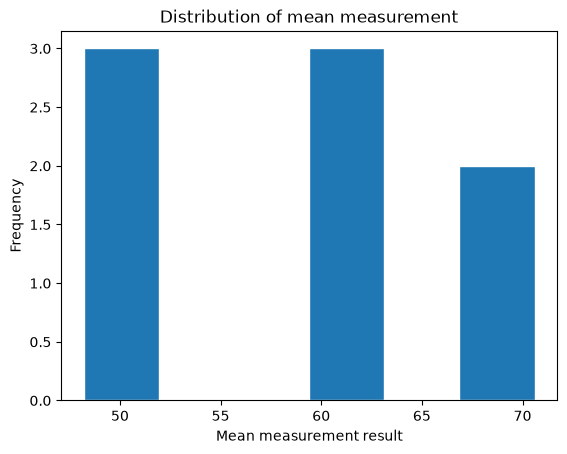

In [109]:
import matplotlib.pyplot as plt

# Plot 1: distribution of mean_result
n_bins = 6
dist1 = clean_df['mean_result']

fig, ax = plt.subplots()

ax.hist(dist1, bins=n_bins, edgecolor='white')
ax.set_title('Distribution of mean measurement')
ax.set_xlabel('Mean measurement result')
ax.set_ylabel('Frequency')

1. the approximate range;

> The range is 48 - 70

2. whether the values appear concentrated or spread out;

> The results are mostly spread out, with some grouping around 3 distinct points which matches the 3 treatment groups (though it is hard to say this with confidence due to the tiny sample size) 

3. why the tiny sample size limits interpretation of the distribution.

> The small sample size makes it impossible to know whether any trend we see in the data are due to the natural randomness of the data or if they are a real observation. For example, in this dataset the mean measurement result increases from control -> treatment_A -> treatment_B, however it could be that if more data points were collected this trend totally disappears and all three treatment groups may be equally distributed with no clear trends.

Text(0, 0.5, 'Mean measurement')

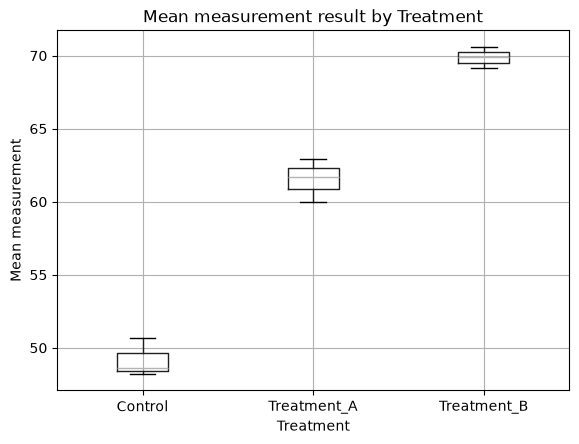

In [110]:
# Plot 2: mean_result by treatment

fig, ax = plt.subplots()

clean_df.boxplot(
  column='mean_result',
  by='treatment',
  ax=ax
)

fig.suptitle('')
ax.set_title('Mean measurement result by Treatment')
ax.set_xlabel('Treatment')
ax.set_ylabel('Mean measurement')

Before making observations it should once again be reiterated that the sample sizes for this experiment are too small to make any meaningful conclusions. The data does suggest that there is a trend of increasing measurement from Treatment_A compared to the control, and further still increasing measurement with Treatment_B. Therefore a follow up study should be performed to test this trend with a larger sample size.

## 8. Limitations

- A larger sample size is essential to be able to draw any conclusions from this experiment, however this study does provide a good baseline to test against in a follow experiment.

- When cleaning up the data, it was decided that missing temperature data should be replaced by the median of the non-missing temperature data. This is bad practice and in future these results should be discarded from the dataset. These results were left in due to the already small sample size which would have become unworkably small if additional rows were removed due to missing temperature data.

- Temperature increases as treatment changes from control -> Treatment_A -> Treatment_B, therefore we do not known if the increasing trend in measurement results is due to the changing treatment or due the increasing temperature

## Session reflection

### What makes a notebook reproducible?
- the same input files and recorded dependencies;
- cells arranged in a logical order;
- no reliance on hidden notebook state;
- restarting the kernel and successfully running all cells from top to bottom.

### What is the difference between describing a pattern and claiming causation?
Describing a pattern is simply describing the data, saying that two variables may be correlated. Claiming causation requires a much more in depth understanding as it inteprets the data as causal in that changing one variable directly causes another variable to change.

### Why are group means potentially misleading with very small groups?
Means are generally only useful with larger sample sizes since this eliminates some of the enate randomness that comes from sampling. 

### Which pandas operation did I still need to look up?
I needed to look up agg(), as i forgot the syntax for output=('source_column', 'function')

### First task next session
Setting up an interactive python note book in a virtual environment